In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '122',
        '--data_nsample_exc', '528',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--lookback_nsample', '64',
        '--forecast_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '32',
        '--seg_nsample_trans', '16',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
_, _, data_loader = dataset.load(data_type='mixed')

data_path = '../../data/dreamer/duffing_all_0.csv'
dataframe = pd.read_csv(data_path, header=None, dtype=np.float32)
replay = torch.unsqueeze(torch.from_numpy(dataframe.to_numpy()), 0)
print(replay.shape)

torch.Size([1, 626, 4])


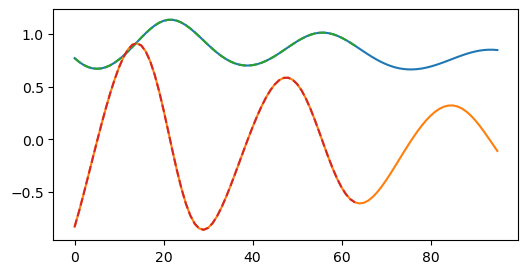

In [5]:
jdata = 3
offset = 90

with torch.no_grad():
    for back_n, fore_n in data_loader:
        true_n = torch.cat([back_n, fore_n], dim=1)

        true = replay[:, offset:offset + args.lookback_nsample + args.forecast_nsample]
        back = replay[:, offset:offset + args.lookback_nsample]

        true, _ = dataset.normalizer.normalize(true)
        back, _ = dataset.normalizer.normalize(back)

        plt.figure(figsize=(6,3))
        #plt.plot(true_n[jdata, :, :2])
        plt.plot(true[0, :, :2])
        plt.plot(back[0, :, :2], linestyle='dashed')
        break

#print(tata.shape)

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=1.053575, valid=1.063512, test=1.037656
	validation loss decreased (inf -> 1.063512), saving model ...
	epoch 2 losses: train=1.032657, valid=1.047463, test=1.019927
	validation loss decreased (1.063512 -> 1.047463), saving model ...
	epoch 3 losses: train=1.017652, valid=1.027639, test=1.002902
	validation loss decreased (1.047463 -> 1.027639), saving model ...
	epoch 4 losses: train=1.003827, valid=1.012884, test=0.984944
	validation loss decreased (1.027639 -> 1.012884), saving model ...
	epoch 5 losses: train=0.992471, valid=0.995749, test=0.965527
	validation loss decreased (1.012884 -> 0.995749), saving model ...
	epoch 6 losses: train=0.979990, valid=0.975241, test=0.943119
	validation loss decreased (0.995749 -> 0.975241), saving model ...
	epoch 7 losses: train=0.965863, valid=0.952838, test=0.917781
	validation loss decreased (0.975241 -> 0.952838), saving model ...
	epoch 8 losses: train=0.951060, valid=0.927512, test=0.88

In [7]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

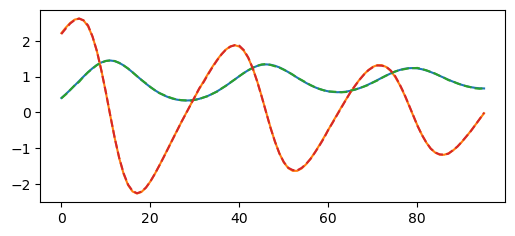

In [8]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break

#print(tata.shape)

In [9]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.980280, valid=1.218790, test=0.723646
	validation loss decreased (inf -> 1.218790), saving model ...
	epoch 2 losses: train=0.963171, valid=1.207360, test=0.717031
	validation loss decreased (1.218790 -> 1.207360), saving model ...
	epoch 3 losses: train=0.953246, valid=1.195215, test=0.710041
	validation loss decreased (1.207360 -> 1.195215), saving model ...
	epoch 4 losses: train=0.944128, valid=1.181838, test=0.703379
	validation loss decreased (1.195215 -> 1.181838), saving model ...
	epoch 5 losses: train=0.934996, valid=1.168101, test=0.696515
	validation loss decreased (1.181838 -> 1.168101), saving model ...
	epoch 6 losses: train=0.925286, valid=1.153509, test=0.688769
	validation loss decreased (1.168101 -> 1.153509), saving model ...
	epoch 7 losses: train=0.914964, valid=1.137408, test=0.680096
	validation loss decreased (1.153509 -> 1.137408), saving model ...
	epoch 8 losses: train=0.903699, valid=1.119424, te

In [10]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

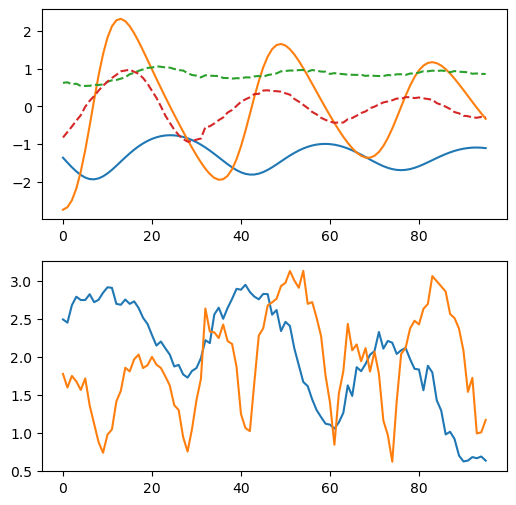

In [11]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break

#print(tata.shape)

In [12]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.914493, valid=0.929470, test=1.024132
	validation loss decreased (inf -> 0.929470), saving model ...
	epoch 2 losses: train=0.940187, valid=0.893590, test=1.013852
	validation loss decreased (0.929470 -> 0.893590), saving model ...
	epoch 3 losses: train=0.931324, valid=0.880362, test=1.011703
	validation loss decreased (0.893590 -> 0.880362), saving model ...
	epoch 4 losses: train=0.917533, valid=0.839244, test=1.008060
	validation loss decreased (0.880362 -> 0.839244), saving model ...
	epoch 5 losses: train=0.831278, valid=0.685231, test=0.956278
	validation loss decreased (0.839244 -> 0.685231), saving model ...
	epoch 6 losses: train=0.738099, valid=0.638597, test=0.869212
	validation loss decreased (0.685231 -> 0.638597), saving model ...
	epoch 7 losses: train=0.671288, valid=0.583926, test=0.806559
	validation loss decreased (0.638597 -> 0.583926), saving model ...
	epoch 8 losses: train=0.583417, valid=0.576167, test=0.

In [13]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

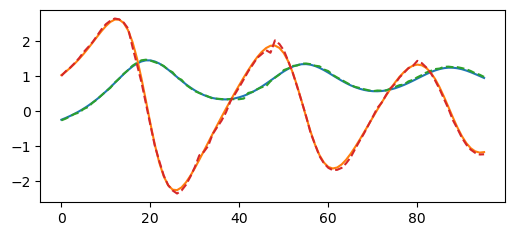

In [14]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [15]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.135509, valid=0.070849, test=0.051848
	validation loss decreased (inf -> 0.070849), saving model ...
	epoch 2 losses: train=0.092847, valid=0.067074, test=0.045806
	validation loss decreased (0.070849 -> 0.067074), saving model ...
	epoch 3 losses: train=0.090296, valid=0.063805, test=0.041901
	validation loss decreased (0.067074 -> 0.063805), saving model ...
	epoch 4 losses: train=0.085042, valid=0.060291, test=0.038429
	validation loss decreased (0.063805 -> 0.060291), saving model ...
	epoch 5 losses: train=0.081810, valid=0.057823, test=0.036013
	validation loss decreased (0.060291 -> 0.057823), saving model ...
	epoch 6 losses: train=0.078500, valid=0.056295, test=0.034517
	validation loss decreased (0.057823 -> 0.056295), saving model ...
	epoch 7 losses: train=0.078133, valid=0.055330, test=0.033464
	validation loss decreased (0.056295 -> 0.055330), saving model ...
	epoch 8 losses: train=0.077018, valid=0.054704, 

In [16]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

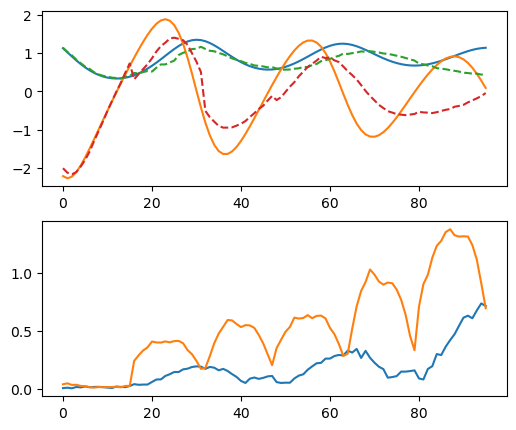

In [17]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

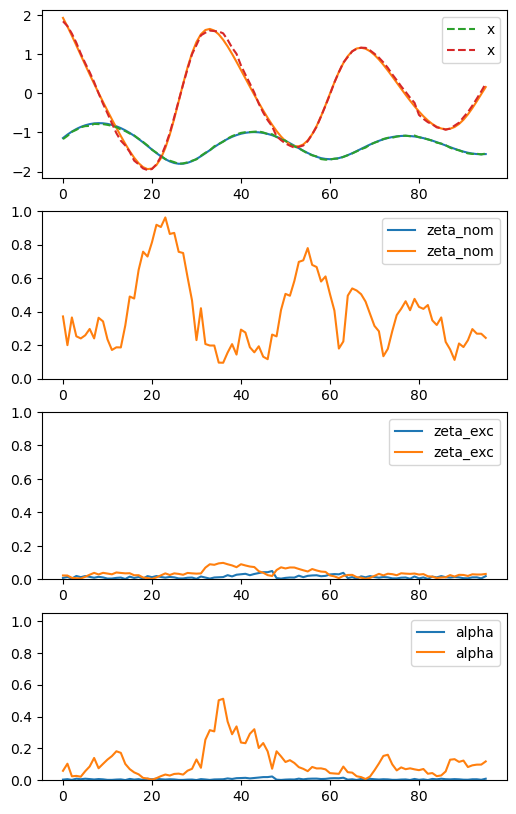

In [18]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break